In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, 
                             confusion_matrix, roc_auc_score)
import warnings
warnings.filterwarnings("ignore")

In [12]:
df = pd.read_csv('data_for_predictions.csv')
print("Shape:", df.shape)
print(df.head(3))

Shape: (14606, 64)
   Unnamed: 0                                id  cons_12m  cons_gas_12m  \
0           0  24011ae4ebbe3035111d65fa7c15bc57  0.000000      4.739944   
1           1  d29c2c54acc38ff3c0614d0a653813dd  3.668479      0.000000   
2           2  764c75f661154dac3a6c254cd082ea7d  2.736397      0.000000   

   cons_last_month  forecast_cons_12m  forecast_discount_energy  \
0              0.0           0.000000                       0.0   
1              0.0           2.280920                       0.0   
2              0.0           1.689841                       0.0   

   forecast_meter_rent_12m  forecast_price_energy_off_peak  \
0                 0.444045                        0.114481   
1                 1.237292                        0.145711   
2                 1.599009                        0.165794   

   forecast_price_energy_peak  ...  months_modif_prod  months_renewal  \
0                    0.098142  ...                  2               6   
1               

In [3]:
# Prepare features and target
# Drop id column and any text/object columns (not numeric — model cannot use them)
cols_to_drop = ["id"]
if "Unnamed: 0" in df.columns:
    cols_to_drop.append("Unnamed: 0")

text_cols = df.select_dtypes(include="object").columns.tolist()
print("Text columns found (dropping):", text_cols)

df_model = df.drop(columns=cols_to_drop + text_cols, errors="ignore")

# Split into features (X) and target (y)
X = df_model.drop(columns=["churn"])
y = df_model["churn"]

churn_rate = y.mean() * 100
print("Text columns to drop:", text_cols)
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print(f"Churn rate: {churn_rate:.2f} %")

Text columns to drop: ['id']
Features shape: (14606, 62)
Target shape: (14606,)
Churn rate: 9.72 %


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (11684, 62)
Test set size: (2922, 62)


In [5]:
# Build Random Forest with 100 trees
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [6]:
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Predictions done!")
print("Sample predictions:", y_pred[:10])

Predictions done!
Sample predictions: [0 0 0 0 0 0 1 0 0 0]


In [7]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc_roc   = roc_auc_score(y_test, y_pred_proba)

print("=" * 40)
print("MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"Accuracy:  {round(accuracy  * 100, 2)}%")
print(f"Precision: {round(precision * 100, 2)}%")
print(f"Recall:    {round(recall    * 100, 2)}%")
print(f"F1 Score:  {round(f1        * 100, 2)}%")
print(f"AUC-ROC:   {round(auc_roc,  4)}")

MODEL EVALUATION RESULTS
Accuracy:  85.22%
Precision: 28.11%
Recall:    33.45%
F1 Score:  30.55%
AUC-ROC:   0.6852


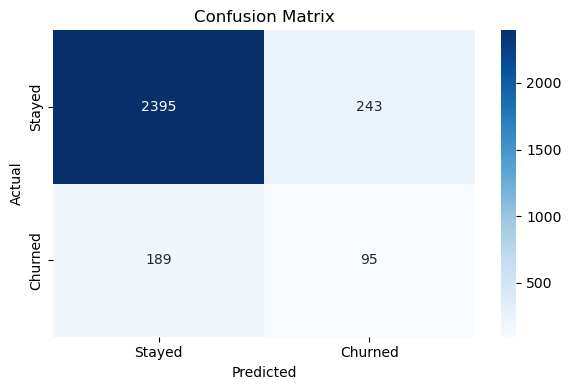

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

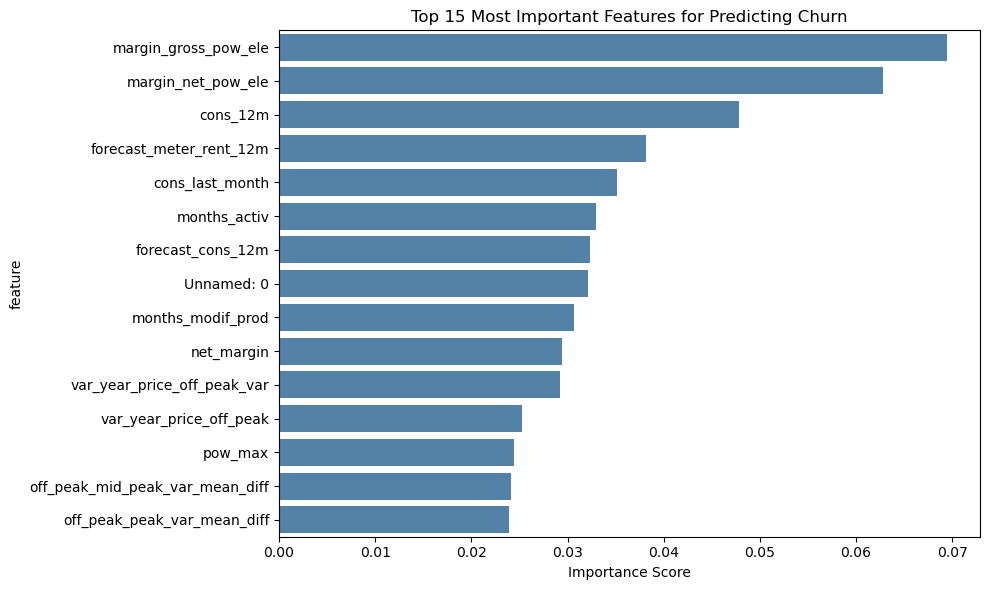

                            feature  importance
12             margin_gross_pow_ele    0.069413
13               margin_net_pow_ele    0.062805
1                          cons_12m    0.047859
6           forecast_meter_rent_12m    0.038112
3                   cons_last_month    0.035164
50                     months_activ    0.033001
4                 forecast_cons_12m    0.032300
0                        Unnamed: 0    0.032163
52                months_modif_prod    0.030625
15                       net_margin    0.029385
17      var_year_price_off_peak_var    0.029211
23          var_year_price_off_peak    0.025261
16                          pow_max    0.024464
39  off_peak_mid_peak_var_mean_diff    0.024129
37      off_peak_peak_var_mean_diff    0.023961


In [9]:
# Which features mattered most?
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', color='steelblue')
plt.title('Top 15 Most Important Features for Predicting Churn')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importance_df)

## Model Evaluation Summary

### Why these metrics?
- **Accuracy (85.22%)** is misleading here because only ~10% of customers churn. A model that predicts "no churn" for everyone would be 90.3% accurate — but completely useless.
- **Recall (33.45%)** is the most important metric. Out of all customers who actually churned, we caught 33%. Missing a churner means they leave without PowerCo being able to act.
- **Precision (28.11%)** — when the model flags a customer as likely to churn, it is correct ~28% of the time. False alarms are cheaper than missed churners.
- **AUC-ROC (0.6852)** — 0.5 = random guessing, 1.0 = perfect. Our model has genuine predictive signal, but improvement is needed.

### Key Business Finding
Feature importance shows that **net margin and electricity consumption** are stronger predictors of churn than price difference features alone.
This means PowerCo's original hypothesis — that price sensitivity drives churn — is **not fully supported by the data**.

### Next Steps to Improve the Model
- Apply **SMOTE** to handle class imbalance instead of only 
- Try **XGBoost** or **LightGBM** which often outperform Random Forest on tabular data
- Perform **hyperparameter tuning** (GridSearchCV on n_estimators, max_depth, min_samples_leaf)
- Target: **Recall > 60%** before production deployment